# Feature Aggregation
by DM

In [1]:
%cd ..
%load_ext autoreload
%autoreload 2

/home/dongmin/userdata/dongmin/Robot-Radio-Station


In [2]:
from pathlib import Path
from collections import defaultdict, Counter

import math
import random

import json
import csv

import numpy as np
import pandas as pd

import torch

from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import IPython.display as ipd

clean_uri = lambda uri: uri.split(':')[-1]

/home/dongmin/miniconda3/envs/rrs/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
HOME = Path.home()
CWD = Path.cwd()

In [4]:
DATASET_DIR = HOME / 'userdata' / 'dongmin' / 'smp_dataset'
DATA_DIR = DATASET_DIR / 'data'
META_DIR = CWD / 'metadata'
CRAWL_DIR = CWD / 'data'

## Preprocess

### uniq_songs for aggregation

In [5]:
json_paths = DATA_DIR.glob('*.json')
json_paths = sorted(json_paths, key=lambda x: int(x.stem.split('.')[-1].split('-')[0]))
json_paths = list(json_paths)

len(json_paths), json_paths[:5]

(1000,
 [PosixPath('/home/dongmin/userdata/dongmin/smp_dataset/data/mpd.slice.0-999.json'),
  PosixPath('/home/dongmin/userdata/dongmin/smp_dataset/data/mpd.slice.1000-1999.json'),
  PosixPath('/home/dongmin/userdata/dongmin/smp_dataset/data/mpd.slice.2000-2999.json'),
  PosixPath('/home/dongmin/userdata/dongmin/smp_dataset/data/mpd.slice.3000-3999.json'),
  PosixPath('/home/dongmin/userdata/dongmin/smp_dataset/data/mpd.slice.4000-4999.json')])

In [6]:
playlists = []

for j_p in json_paths:
  with open(j_p, 'r') as f:
    chunk = json.load(f)
    playlists += chunk['playlists']

len(playlists), playlists[0]

(1000000,
 {'name': 'Throwbacks',
  'collaborative': 'false',
  'pid': 0,
  'modified_at': 1493424000,
  'num_tracks': 52,
  'num_albums': 47,
  'num_followers': 1,
  'tracks': [{'pos': 0,
    'artist_name': 'Missy Elliott',
    'track_uri': 'spotify:track:0UaMYEvWZi0ZqiDOoHU3YI',
    'artist_uri': 'spotify:artist:2wIVse2owClT7go1WT98tk',
    'track_name': 'Lose Control (feat. Ciara & Fat Man Scoop)',
    'album_uri': 'spotify:album:6vV5UrXcfyQD1wu4Qo2I9K',
    'duration_ms': 226863,
    'album_name': 'The Cookbook'},
   {'pos': 1,
    'artist_name': 'Britney Spears',
    'track_uri': 'spotify:track:6I9VzXrHxO9rA9A5euc8Ak',
    'artist_uri': 'spotify:artist:26dSoYclwsYLMAKD3tpOr4',
    'track_name': 'Toxic',
    'album_uri': 'spotify:album:0z7pVBGOD7HCIB7S8eLkLI',
    'duration_ms': 198800,
    'album_name': 'In The Zone'},
   {'pos': 2,
    'artist_name': 'Beyoncé',
    'track_uri': 'spotify:track:0WqIKmW4BTrj3eJFmnCKMv',
    'artist_uri': 'spotify:artist:6vWDO969PvNqNYHIOW5v0m',
    

In [ ]:
# torch.save(playlists, CRAWL_DIR / 'playlists.pt')

In [7]:
track_uri_to_track_tuple = {}
durations = defaultdict(set) # dict of { track_tuple: [duration] }

for p in playlists:
  # list of tuples: [ (artist, album, track, duration) ]
  for t in p['tracks']:
    track_uri = t['track_uri'].strip()
    if track_uri not in track_uri_to_track_tuple:
      track_tuple = (
        t['artist_name'].strip(), 
        t['album_name'].strip(), 
        t['track_name'].strip(),
        t['artist_uri'].strip(),
        t['album_uri'].strip(),
        t['track_uri'].strip()
      )
      track_uri_to_track_tuple[track_uri] = track_tuple

    durations[track_uri].add(t['duration_ms'])

len(track_uri_to_track_tuple)

2262292

In [8]:
# filter classic tracks
classical = set()

for artist, album, track, artist_uri, album_uri, track_uri in track_uri_to_track_tuple.values():
  album_l = album.lower()
  track_l = track.lower()
  
  if ('op. ' in track_l and 'no. ' in track_l and ('minor' in track_l or 'major' in track_l)):
    classical.add(track_uri)
    
  if ('op. ' in album_l and 'no. ' in album_l and ('minor' in album_l or 'major' in album_l)):
    classical.add(track_uri)

len(classical), list(classical)[:5]

(9386,
 ['spotify:track:1iqSCGiTdp86oOwDs2gZUj',
  'spotify:track:5slonxZjQN3fTTORunzuYa',
  'spotify:track:5vYOZ8soXIVvNiBvQAiW9u',
  'spotify:track:4WX4KwOC7vAxAG2hqN814k',
  'spotify:track:51PUq26tnb2W0p3NO7aqTt'])

In [10]:
num_uniq_tracks = len(track_uri_to_track_tuple) - len(classical)
num_uniq_tracks

2252906

In [11]:
for uri_to_del in classical:
  track_uri_to_track_tuple.pop(uri_to_del, None)

len(track_uri_to_track_tuple), len(track_uri_to_track_tuple) == num_uniq_tracks

(2252906, True)

In [13]:
for t in classical:
  durations.pop(t, None)

len(durations.keys()), len(durations.keys()) == num_uniq_tracks

(2252906, True)

In [14]:
durations_mean = { k: np.mean(list(v)) if len(v) > 1 else list(v)[0] for k, v in durations.items() }
durations_std = { k: np.std(list(v)) if len(v) > 1 else 0 for k, v in durations.items() }

In [15]:
all([ v == 0 for v in durations_std.values() ])

True

In [16]:
with open('./data/classical_tracks_250328.csv', 'w') as f:
  writer = csv.writer(f)
  writer.writerow(['track_uri'])
  writer.writerows([(v) for v in list(classical)])

In [ ]:
with open('./data/uniq_tracks_250328.csv', 'w') as f:
  writer = csv.writer(f)
  writer.writerow(['artist', 'album', 'track', 'druation', 'artist_uri', 'album_uri', 'track_uri'])
  
  for track_uri, (artist, album, track, artist_uri, album_uri, track_uri) in track_uri_to_track_tuple.items():
    writer.writerow([artist, album, track, durations_mean[track_uri], artist_uri, album_uri, track_uri])

### Aggregate Data

In [ ]:
with open(CRAWL_DIR / 'uniq_tracks_250328.csv', 'r') as f:
  reader = csv.reader(f)
  uniq_tracks_header = next(reader)
  uniq_tracks = list(reader)
  
len(uniq_tracks), uniq_tracks[:5]

(2252906,
 [['Missy Elliott',
   'The Cookbook',
   'Lose Control (feat. Ciara & Fat Man Scoop)',
   '226863',
   'spotify:artist:2wIVse2owClT7go1WT98tk',
   'spotify:album:6vV5UrXcfyQD1wu4Qo2I9K',
   'spotify:track:0UaMYEvWZi0ZqiDOoHU3YI'],
  ['Britney Spears',
   'In The Zone',
   'Toxic',
   '198800',
   'spotify:artist:26dSoYclwsYLMAKD3tpOr4',
   'spotify:album:0z7pVBGOD7HCIB7S8eLkLI',
   'spotify:track:6I9VzXrHxO9rA9A5euc8Ak'],
  ['Beyoncé',
   'Dangerously In Love (Alben für die Ewigkeit)',
   'Crazy In Love',
   '235933',
   'spotify:artist:6vWDO969PvNqNYHIOW5v0m',
   'spotify:album:25hVFAxTlDvXbx2X2QkUkE',
   'spotify:track:0WqIKmW4BTrj3eJFmnCKMv'],
  ['Justin Timberlake',
   'Justified',
   'Rock Your Body',
   '267266',
   'spotify:artist:31TPClRtHm23RisEBtV3X7',
   'spotify:album:6QPkyl04rXwTGlGlcYaRoW',
   'spotify:track:1AWQoqb9bSvzTjaLralEkT'],
  ['Shaggy',
   'Hot Shot',
   "It Wasn't Me",
   '227600',
   'spotify:artist:5EvFsr3kj42KNv97ZEnqij',
   'spotify:album:6NmFmPX

In [21]:
uniq_tracks_header

['artist',
 'album',
 'track',
 'druation',
 'artist_uri',
 'album_uri',
 'track_uri']

In [48]:
track_uri_to_track_tuple = {}
track_tuple_to_track_uri = defaultdict(list)

for artist, album, track, duration, artist_uri, album_uri, track_uri in uniq_tracks:
  track_uri_to_track_tuple[track_uri] = (artist, album, track, duration, artist_uri, album_uri, track_uri)
  track_tuple_to_track_uri[(artist, album, track)].append(track_uri)

uri_to_del = []

for k, v in track_tuple_to_track_uri.items():
  if len(v) > 1:
    uri_to_del += v[1:]

for uri in uri_to_del:
  track_uri_to_track_tuple.pop(uri, None)

track_tuple_to_track_uri = { 
  (artist, album, track): track_uri 
  for track_uri, (artist, album, track, *_) in track_uri_to_track_tuple.items()
}

torch.save(track_uri_to_track_tuple, CRAWL_DIR / 'track_uri_to_track_tuple.pt')
torch.save(track_tuple_to_track_uri, CRAWL_DIR / 'track_tuple_to_track_uri.pt')

len(track_uri_to_track_tuple), len(track_tuple_to_track_uri), len(track_uri_to_track_tuple) == len(track_tuple_to_track_uri)

(2247201, 2247201, True)

In [49]:
audio_feature_csv_list = [ p for p in sorted(CRAWL_DIR.glob('track_yt_audio_features_*.csv')) if p.is_file() ]
len(audio_feature_csv_list), audio_feature_csv_list

(6,
 [PosixPath('/home/dongmin/userdata/dongmin/Robot-Radio-Station/data/track_yt_audio_features_2025-03-25-15:53:20.csv'),
  PosixPath('/home/dongmin/userdata/dongmin/Robot-Radio-Station/data/track_yt_audio_features_2025-03-26-11:09:14.csv'),
  PosixPath('/home/dongmin/userdata/dongmin/Robot-Radio-Station/data/track_yt_audio_features_2025-03-26-13:58:50.csv'),
  PosixPath('/home/dongmin/userdata/dongmin/Robot-Radio-Station/data/track_yt_audio_features_2025-03-26-22:38:27.csv'),
  PosixPath('/home/dongmin/userdata/dongmin/Robot-Radio-Station/data/track_yt_audio_features_2025-03-27-02:14:02.csv'),
  PosixPath('/home/dongmin/userdata/dongmin/Robot-Radio-Station/data/track_yt_audio_features_2025-03-28-01:39:52.csv')])

In [50]:
total_audio_features = []

for afc in audio_feature_csv_list:
  with open(afc, 'r') as f:
    reader = csv.reader(f)
    header = next(reader)
    data = list(reader)
  
  for artist, album, track, *rest in data:
    track_tuple = (artist, album, track)
    track_uri = track_tuple_to_track_uri[track_tuple]
    total_audio_features.append([track_uri] + [artist, album, track] + rest)

len(total_audio_features), total_audio_features[:10]

(7620,
 [['spotify:track:76R6MwomrgaSQZvGQDV32h',
   'Leslie Odom Jr.',
   'Simply Christmas',
   'The Christmas Song',
   'CUkwsdBzx48',
   'Leslie Odom Jr. - The Christmas Song (Audio Only)',
   '246',
   '4',
   '0.9570975494384766',
   '0.9403576254844666',
   '1.0',
   '1.0',
   '0.0',
   '5',
   '0.08066500723361969',
   '-16.967971801757812',
   '1',
   '132.1236572265625',
   '4',
   '0.5730314254760742'],
  ['spotify:track:465QyRTmJJBFgdfG6SDpxc',
   'Gary Numan',
   'Hope Bleeds',
   'Absolution',
   'ttpmY1Tp0Bo',
   'Gary Numan - Absolution',
   '300',
   '3',
   '0.9617442352294922',
   '1.0',
   '1.0',
   '1.0',
   '0.0',
   '7',
   '0.19905367493629456',
   '-11.048175811767578',
   '0',
   '88.03230285644531',
   '4',
   '0.3928043842315674'],
  ['spotify:track:7LMs6dgUY3YK9R12uf8TXA',
   'Lazerhawk',
   'Redline',
   'Dream Machine',
   'hB3ibdil2UM',
   'Lazerhawk - Dream Machine',
   '207',
   '3',
   '0.9494231384277344',
   '1.0',
   '1.0',
   '1.0',
   '0.0',
   '

In [51]:
with open(CRAWL_DIR / 'total_audio_features_250328.csv', 'w') as f:
  writer = csv.writer(f)
  writer.writerow(['track_uri'] + header)
  writer.writerows(total_audio_features)

### PDA

In [55]:
features = defaultdict(list)
header = ['track_uri', 'artist', 'album', 'track', 'yt_id', 'yt_title', 'duration_seconds', 'score', 'acousticness', 'danceability', 'energy', 'speechiness', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'tempo', 'time_signature', 'valence'] 

for row in total_audio_features:
  for n, v in zip( header, row ):
    if n in {'track_uri', 'artist', 'album', 'track', 'yt_id', 'yt_title'}:
      features[n].append(v)
      continue
    
    if n in {'duration_seconds', 'key', 'mode'}:
      features[n].append(int(v))
      continue
    
    features[n].append(float(v))

score
min: 1.0
max: 4.0
mean/std: 2.3509186351706037 0.8543269188041618


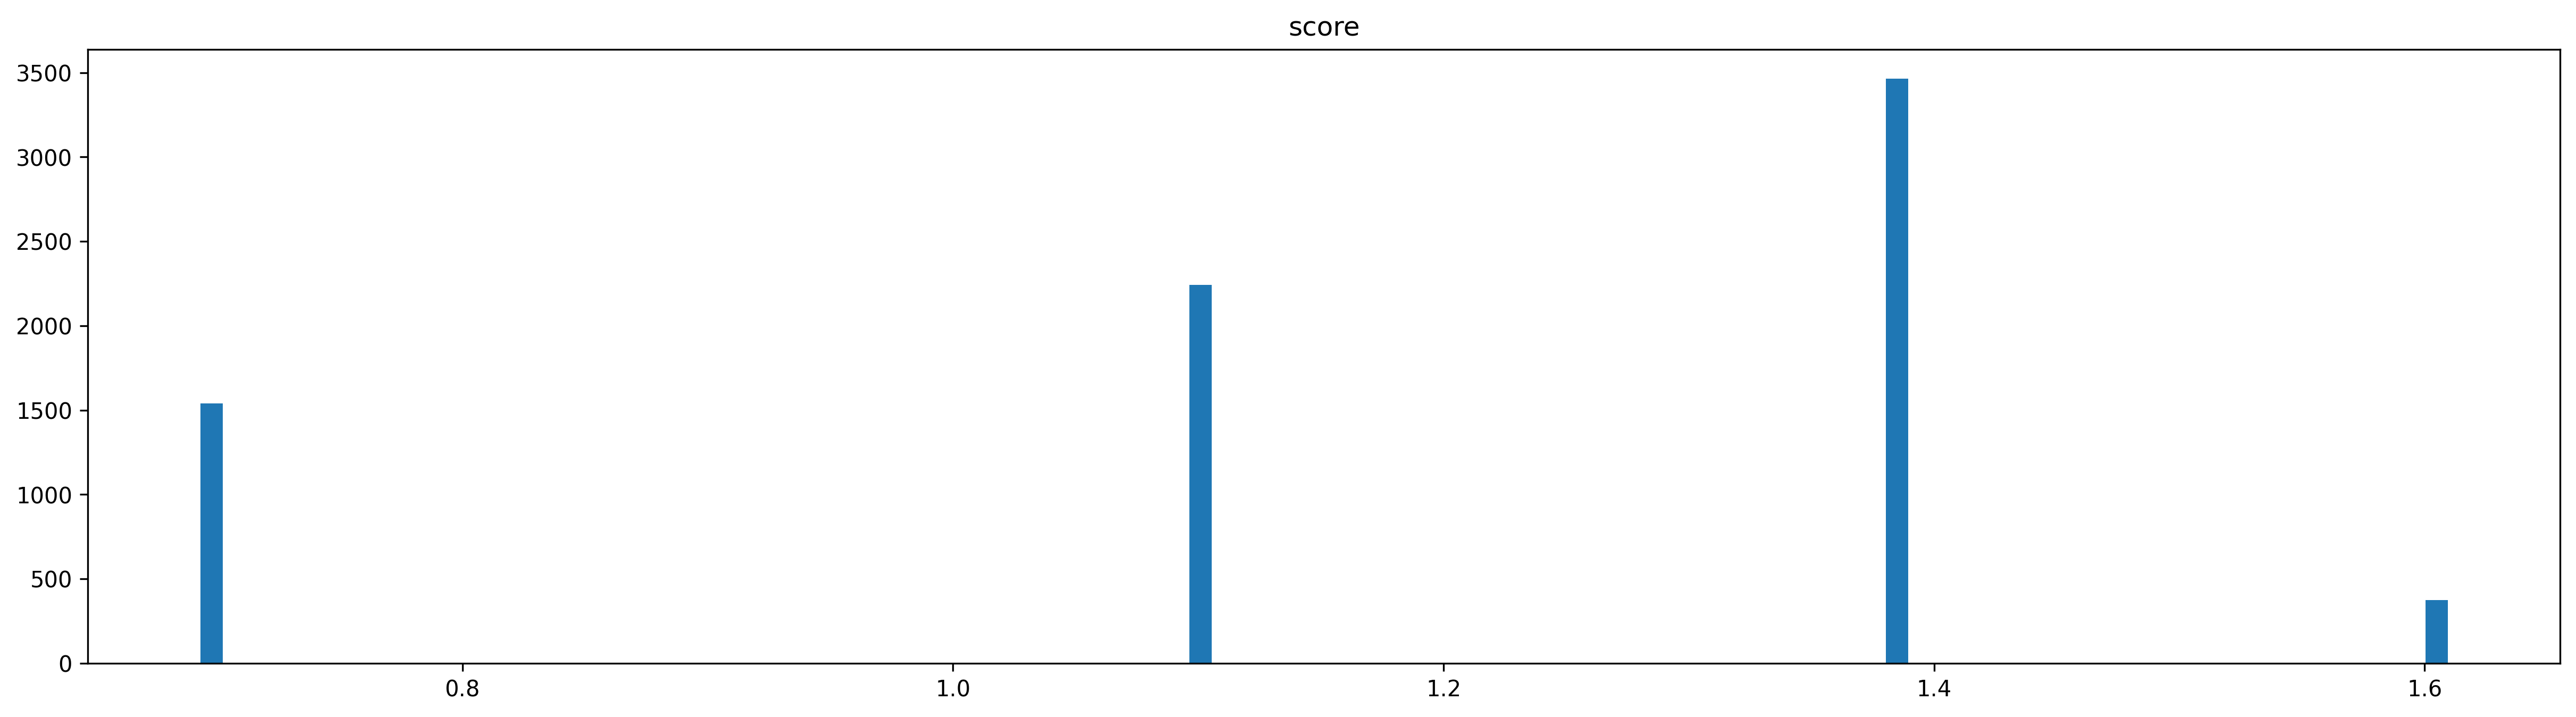

acousticness
min: 0.26061728515625004
max: 0.9907211097717286
mean/std: 0.9188035976813408 0.04005522834096128


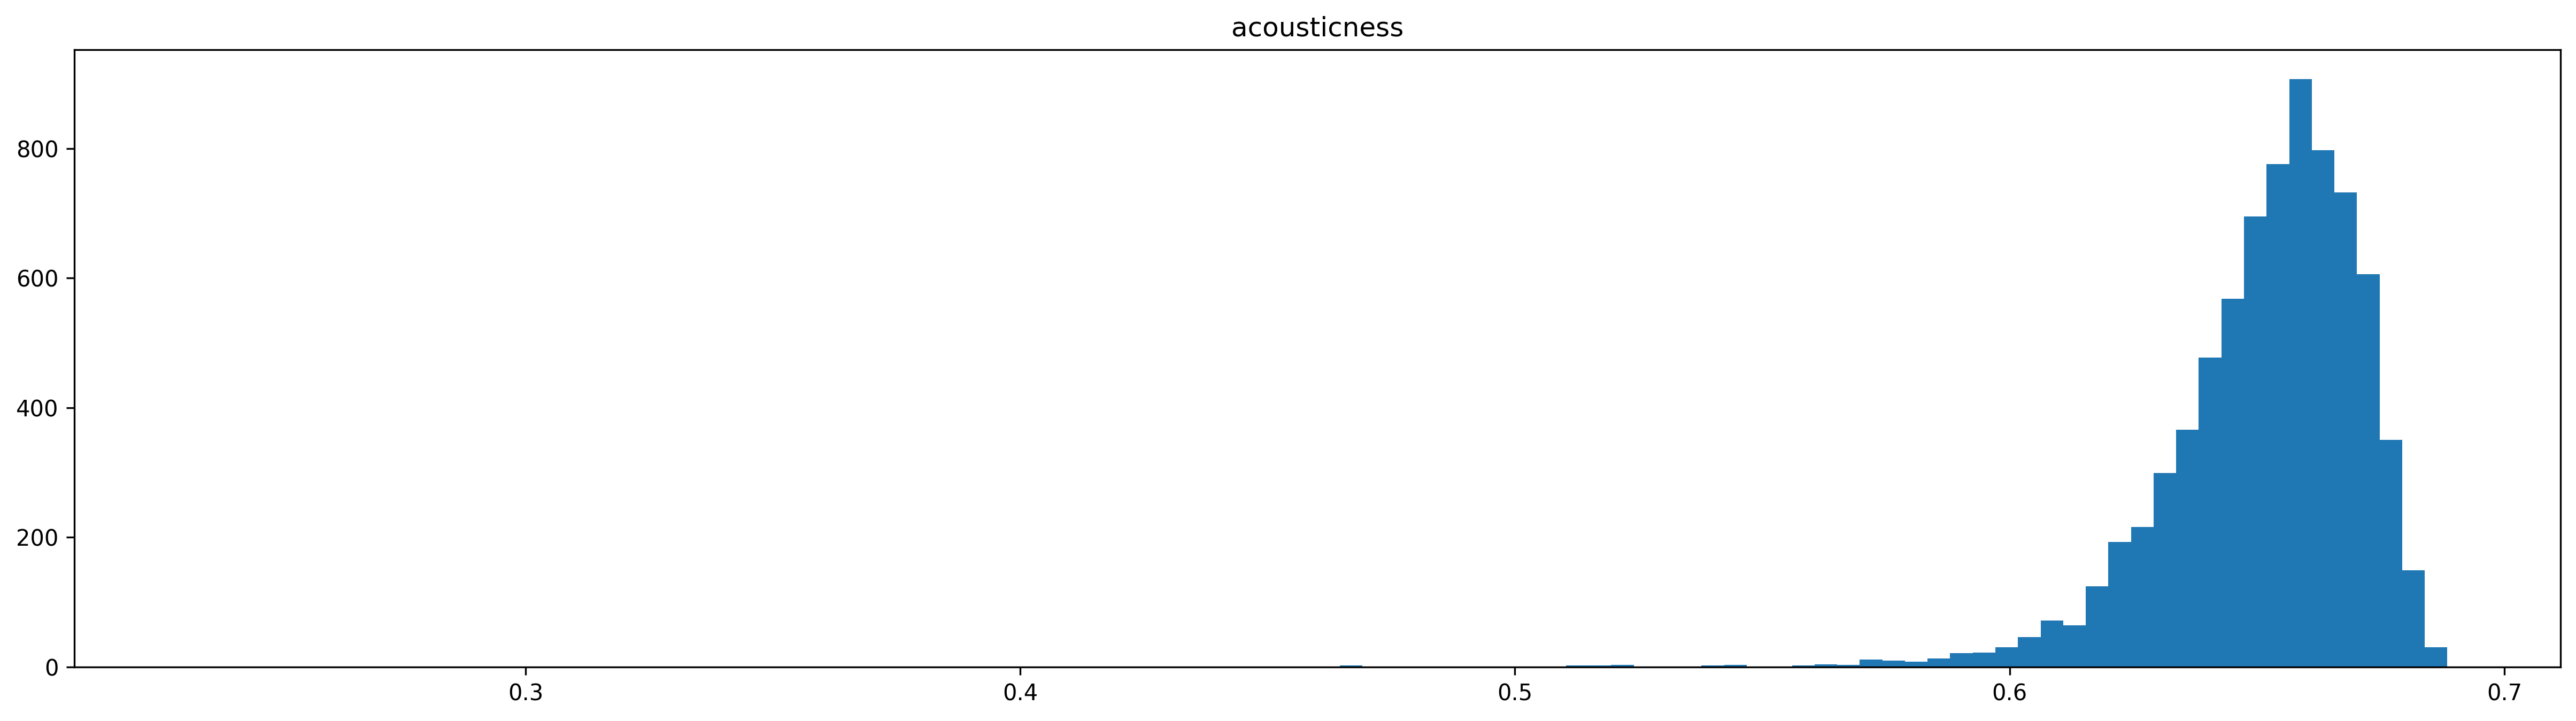

danceability
min: 0.6549780964851379
max: 1.0
mean/std: 0.986096261766326 0.03824357433567303


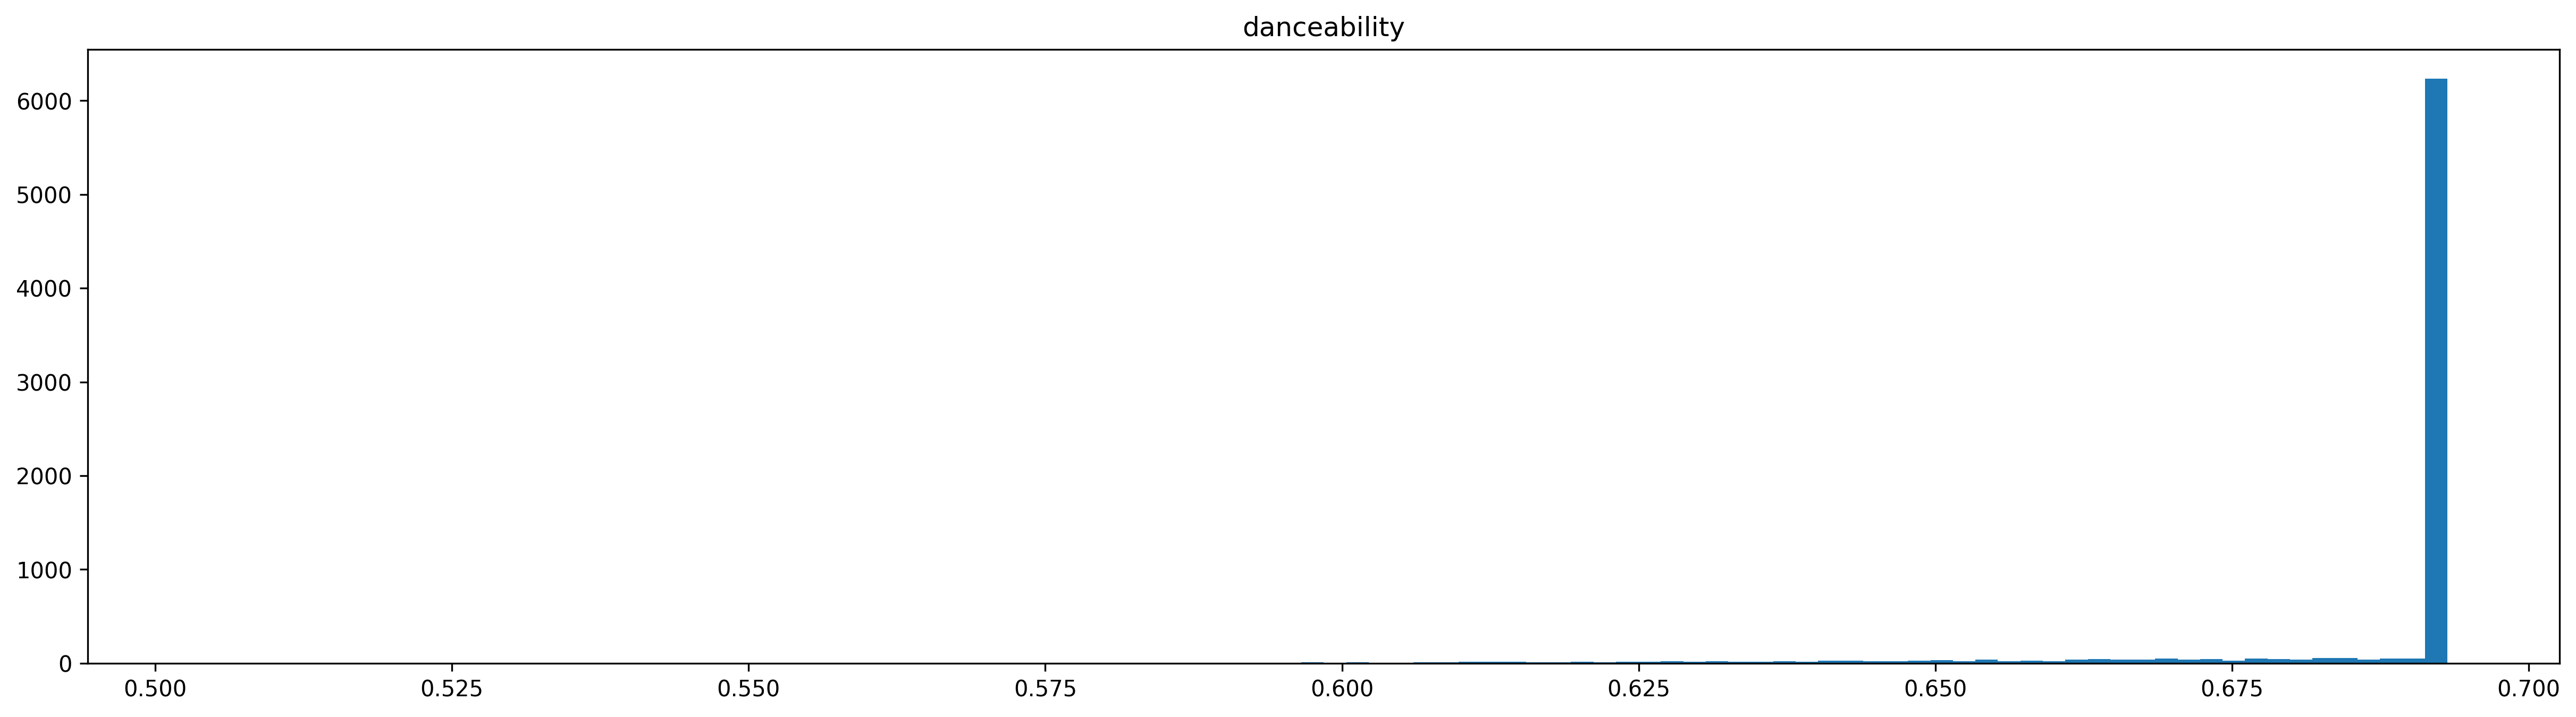

energy
min: 1.0
max: 1.0
mean/std: 1.0 0.0


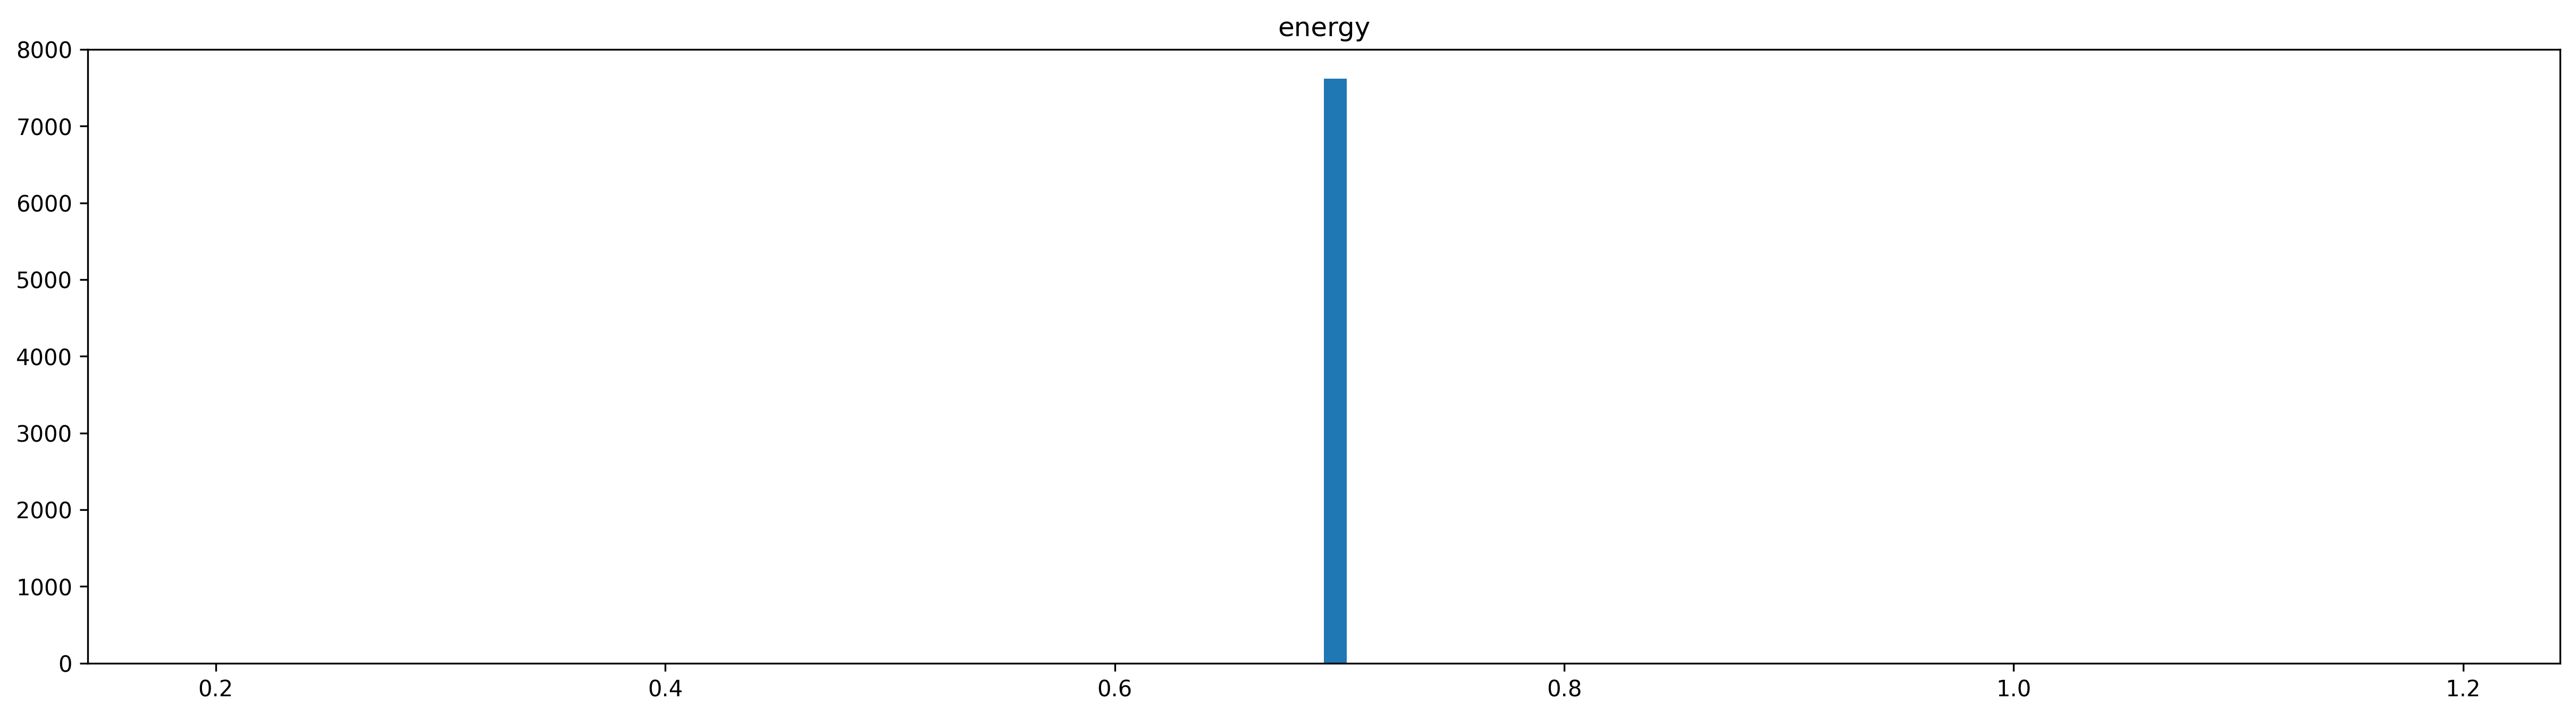

speechiness
min: 0.0
max: 1.0
mean/std: 0.9726748165014222 0.0783692172410277


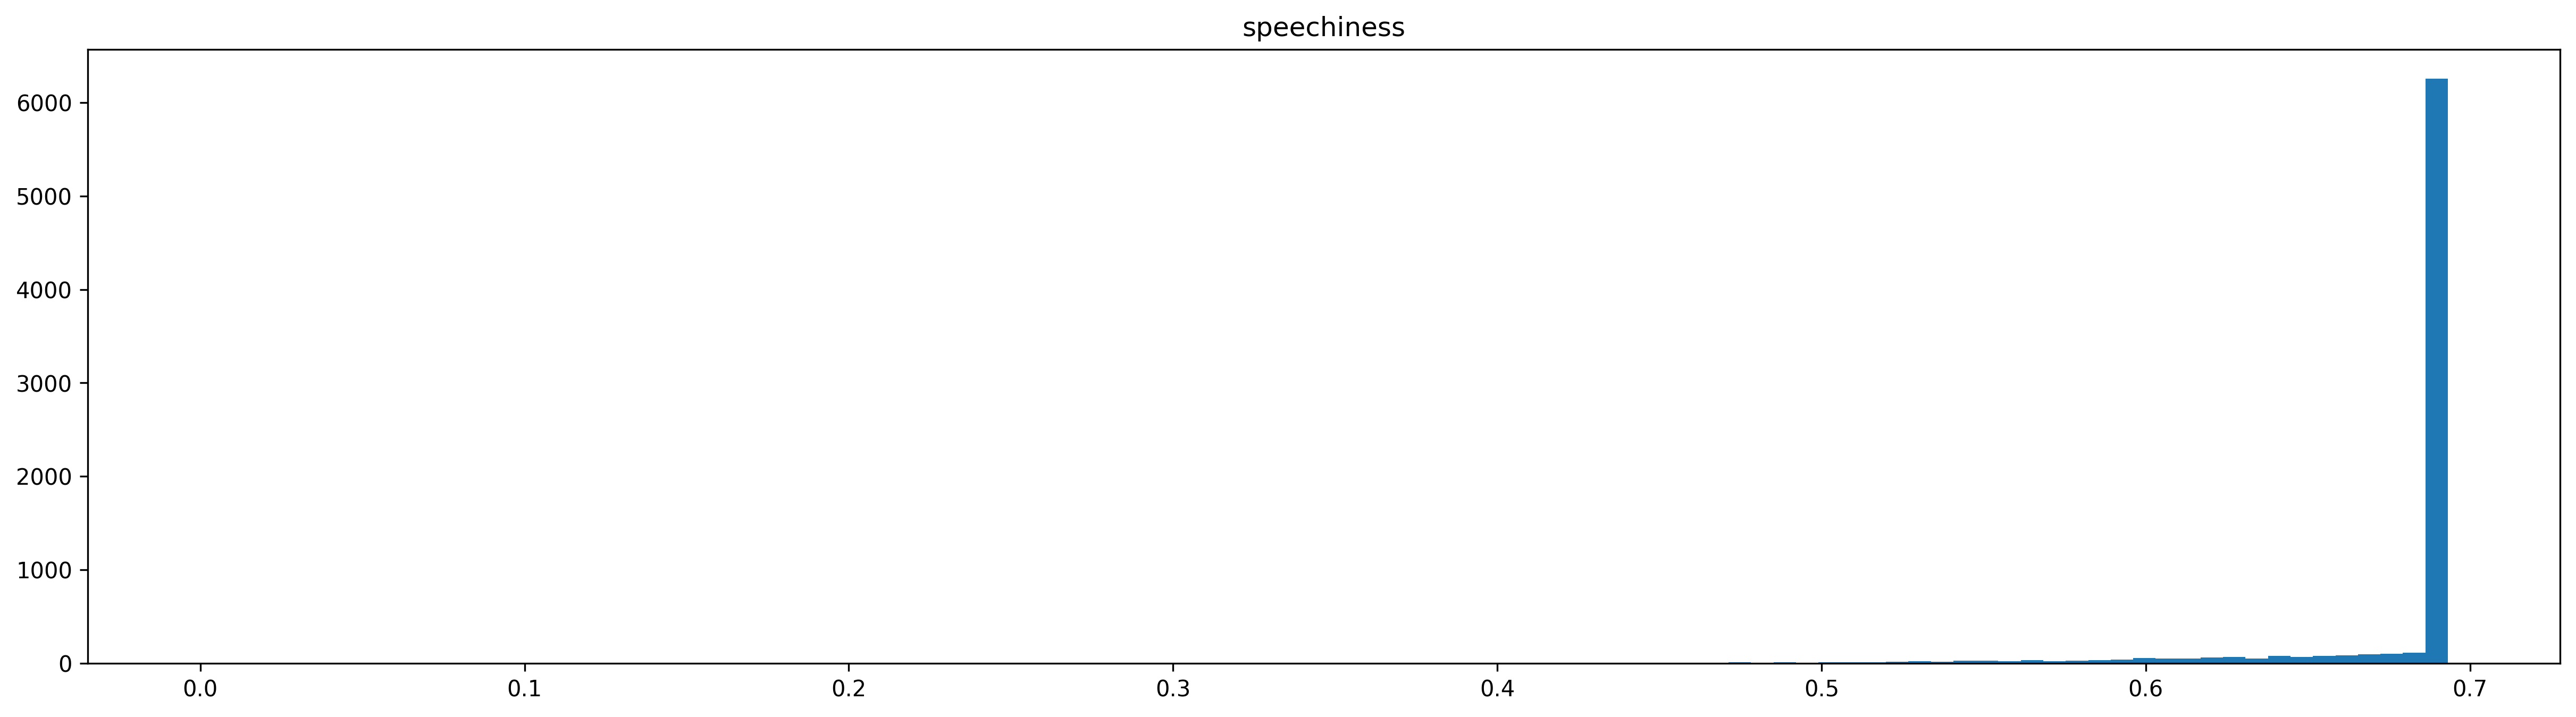

instrumentalness
min: 0.0
max: 1.0
mean/std: 0.027325183498577807 0.0783692172410277


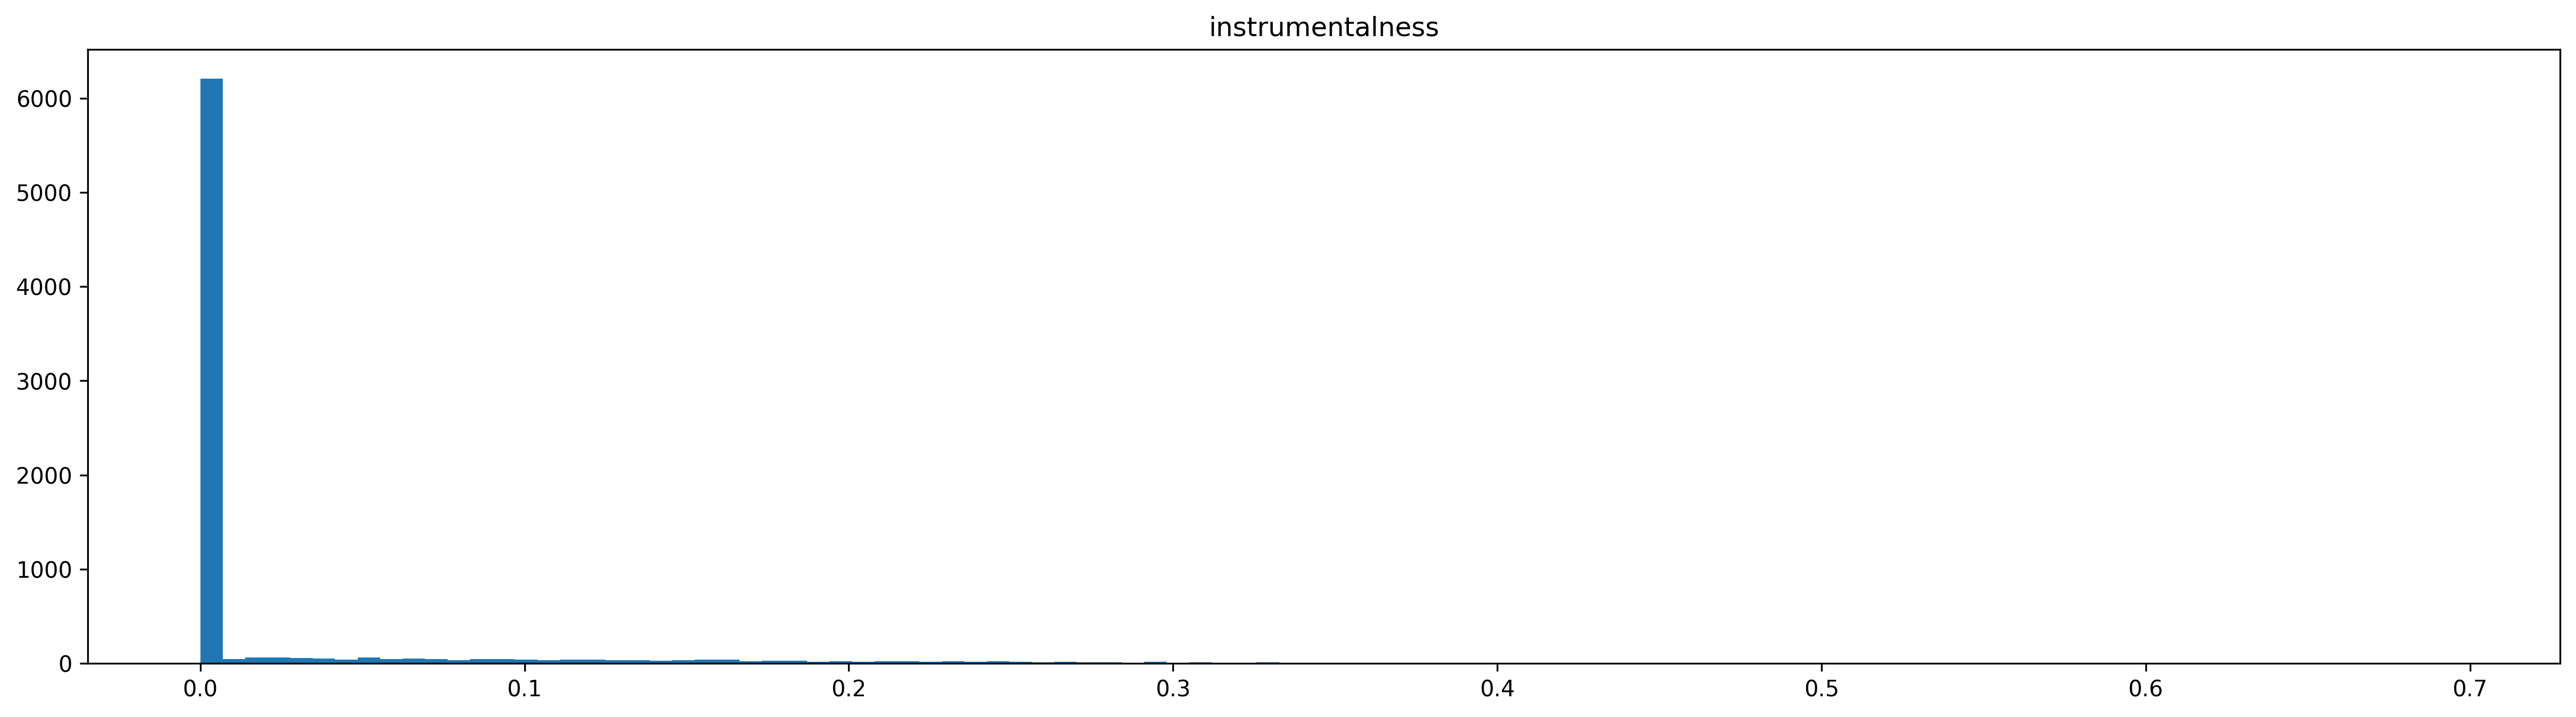

key
min: -1
max: 11
mean/std: 3.688713910761155 3.7401073257216466


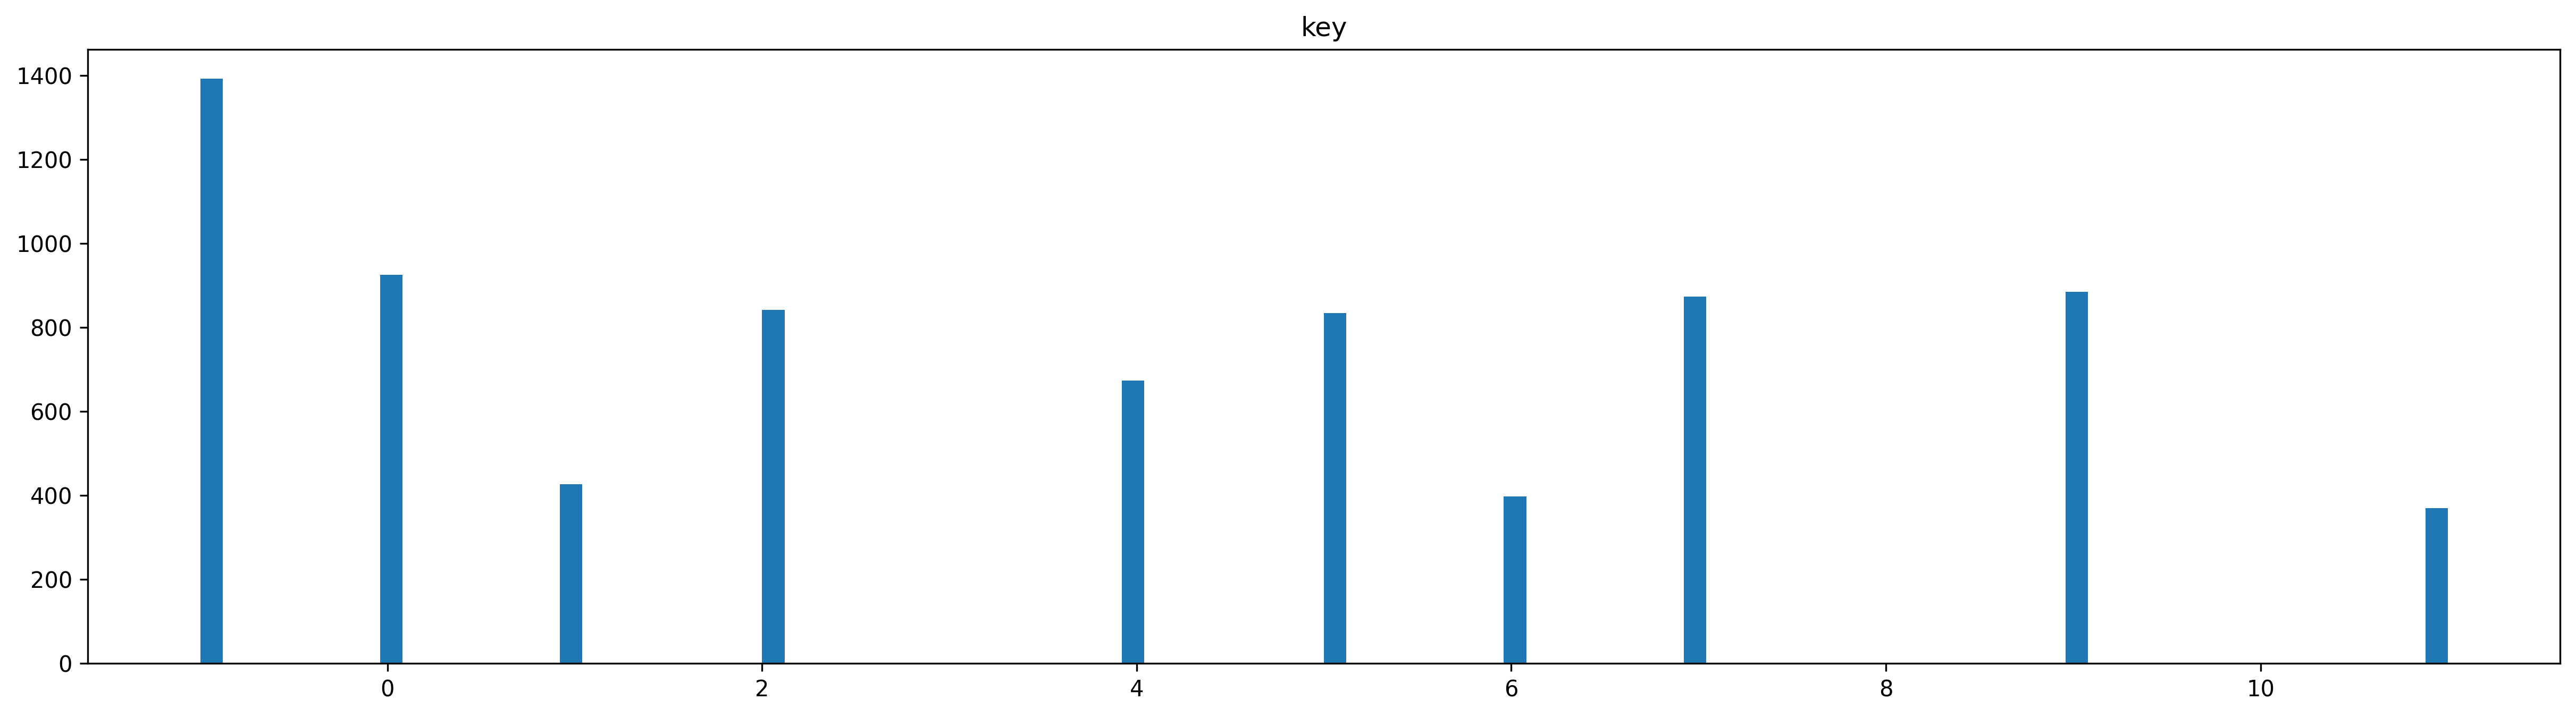

liveness
min: 0.024803301319479942
max: 0.3587861657142639
mean/std: 0.1585087264702213 0.04409328422095547


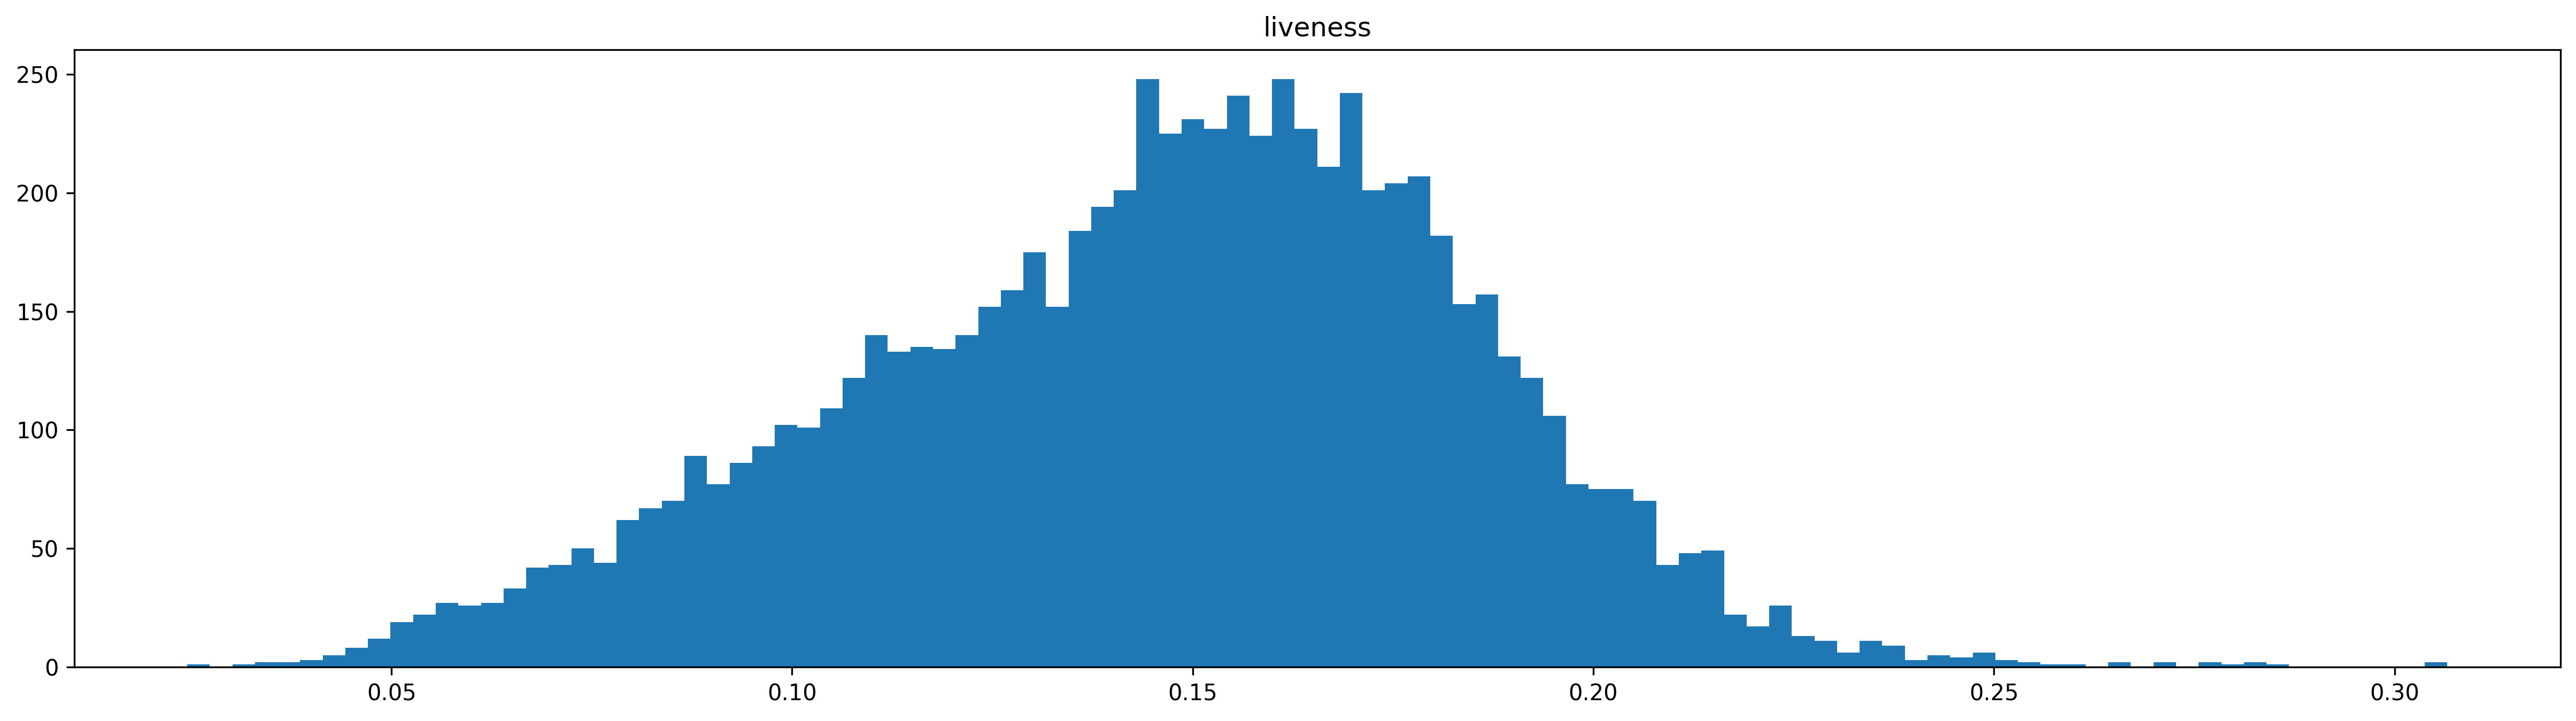

loudness
min: -41.400169372558594
max: -0.5742332339286804
mean/std: -12.11621841293151 4.249970138764496


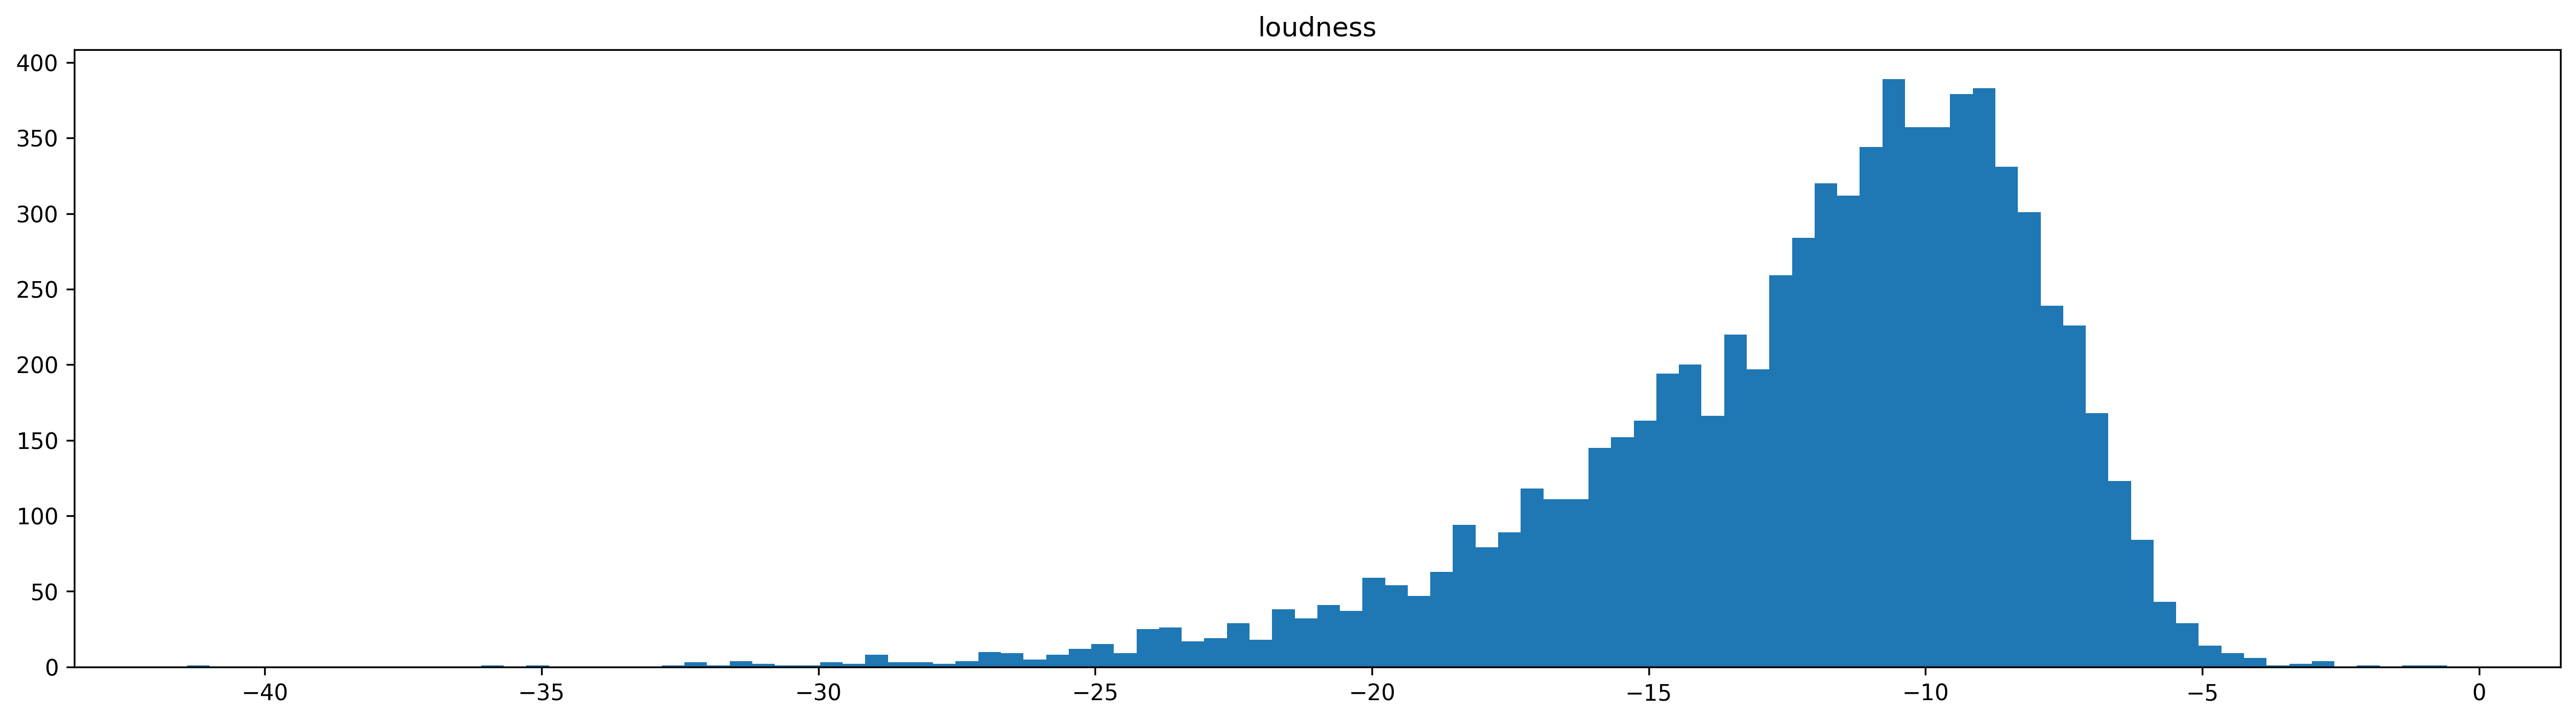

mode
min: 0
max: 1
mean/std: 0.6455380577427822 0.4783499490419735


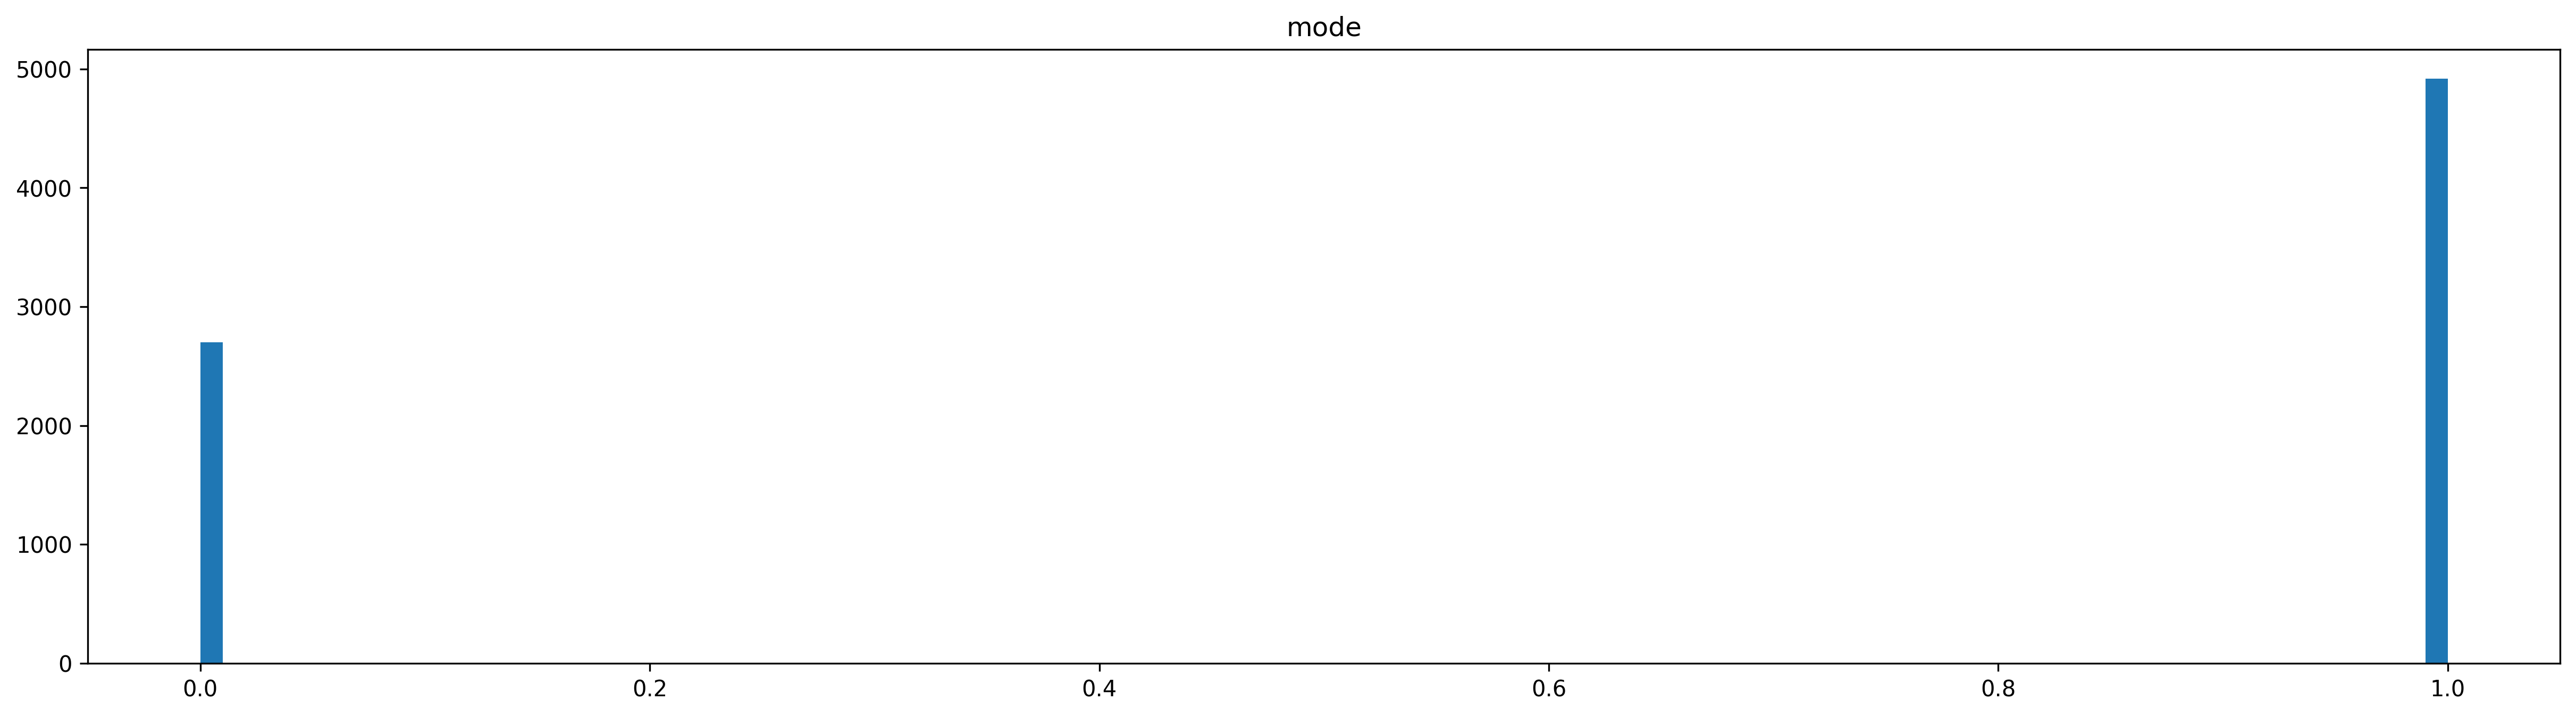

tempo
min: 62.4777717590332
max: 191.40635681152344
mean/std: 122.5758008676564 24.73489575015954


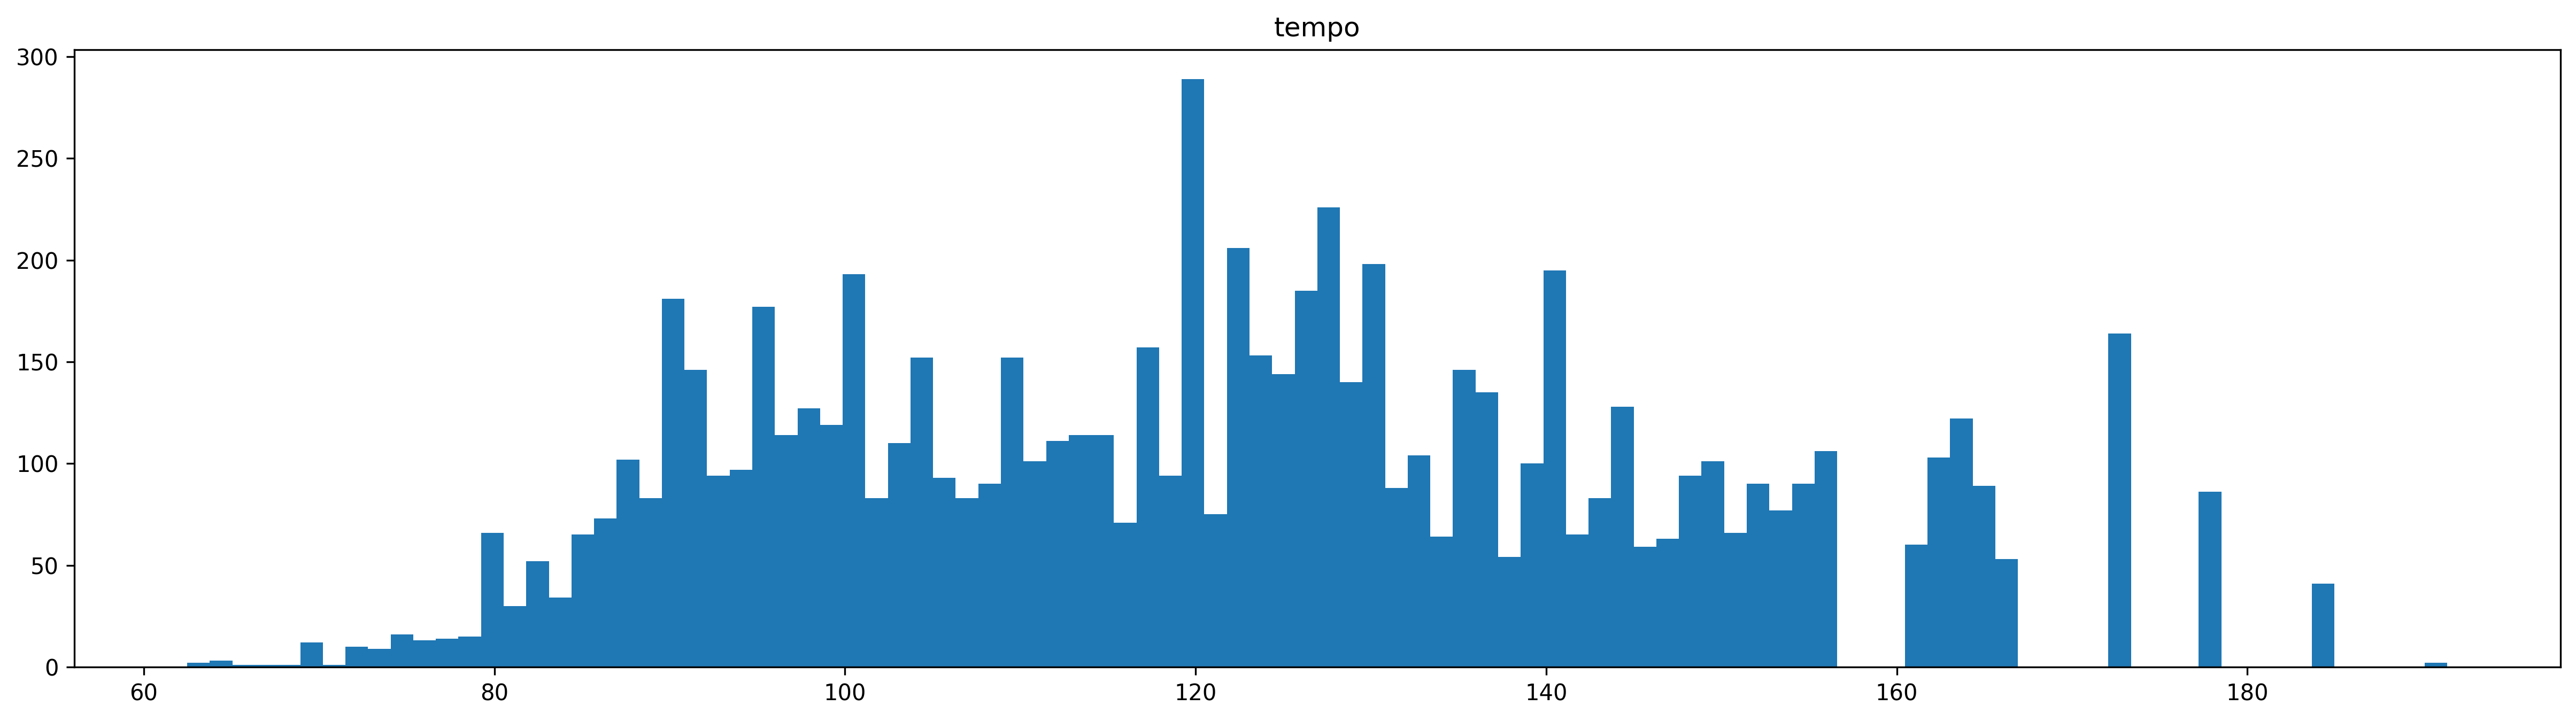

time_signature
min: 4.0
max: 4.0
mean/std: 4.0 0.0


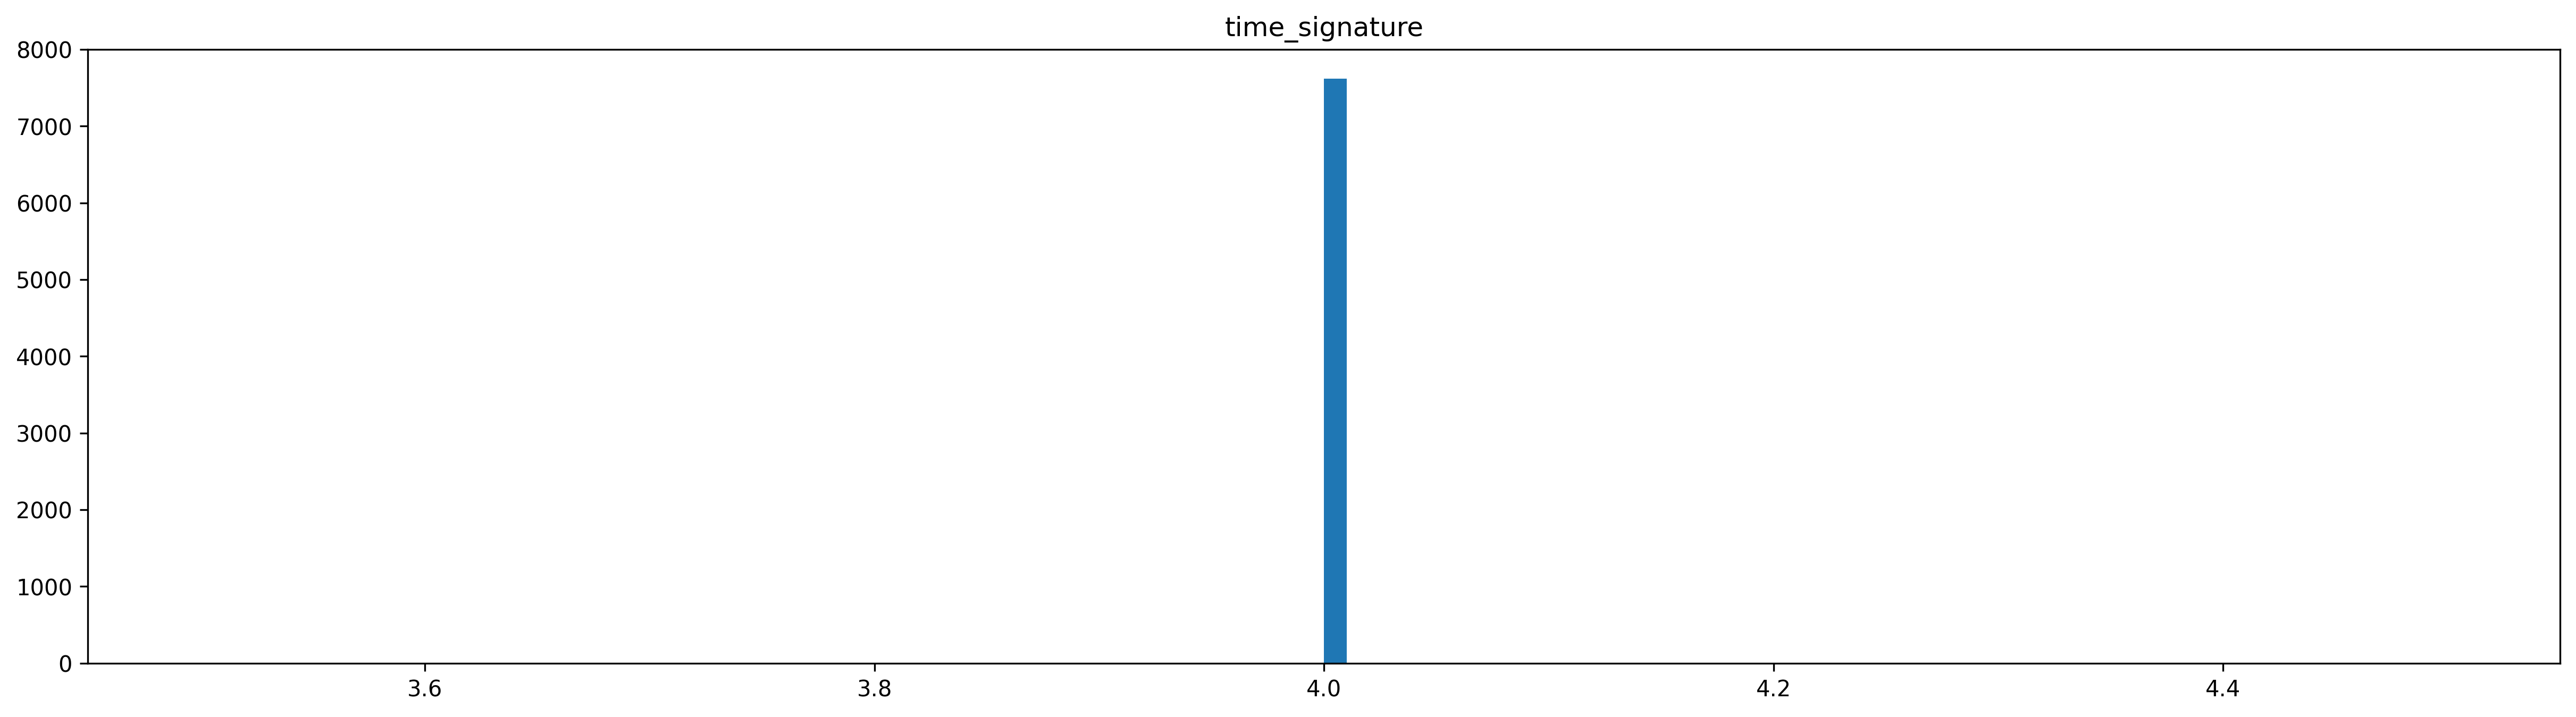

valence
min: 0.17217165231704712
max: 1.0
mean/std: 0.6303815916884603 0.15433868623765118


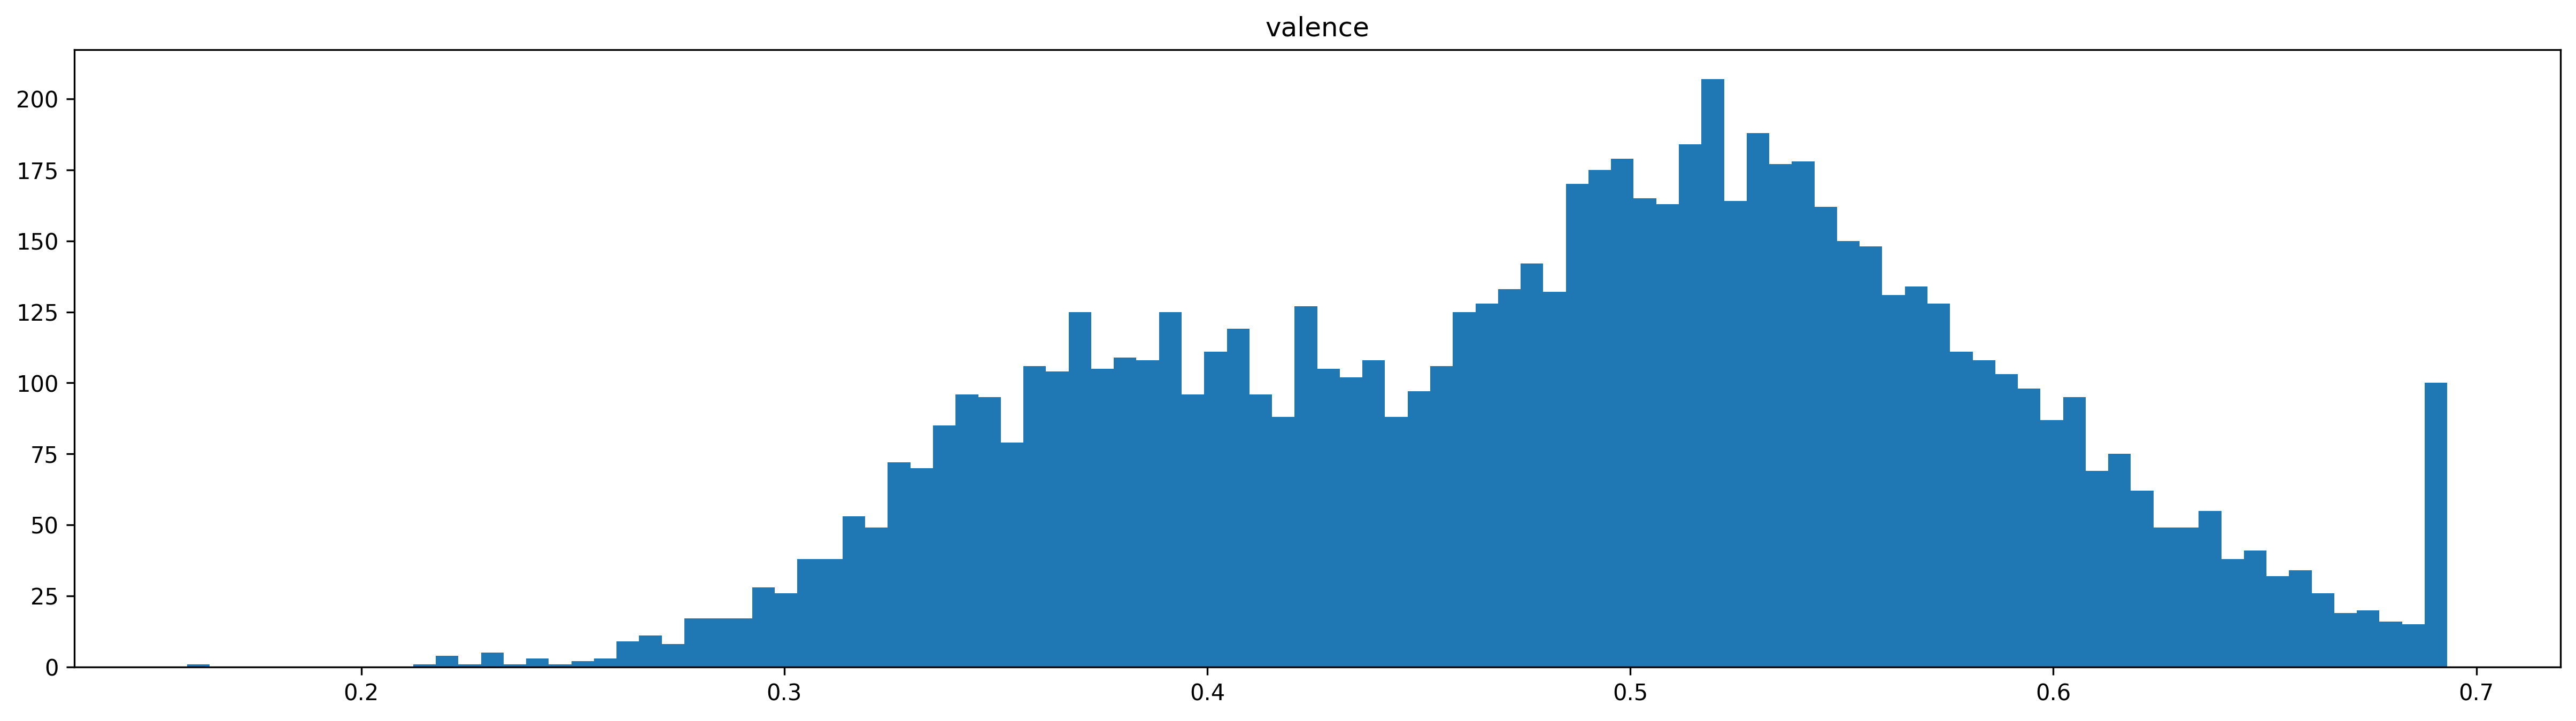

In [56]:
for k, v in features.items():
  if k in {'track_uri', 'artist', 'album', 'track', 'yt_id', 'yt_title', 'duration_seconds'}:
    continue
  
  v = np.array(v)
  
  print(k)
  print('min:', np.min(v))
  print('max:', np.max(v))
  print('mean/std:', np.mean(v), np.std(v))
  
  if k not in {'key', 'mode', 'time_signature', 'loudness', 'tempo'}:
    v = np.log1p(v)
  
  plt.figure(figsize=(20, 5), dpi=300)
  plt.hist(v, bins=100)
  plt.title(k)
  plt.show()

In [57]:
# drop 'time_signature' and 'energe'
with open(CRAWL_DIR / 'total_audio_features_250328_drop.csv', 'w') as f:
  writer = csv.writer(f)
  writer.writerow(['track_uri', 'artist', 'album', 'track', 'yt_id', 'yt_title', 'duration_seconds', 'score', 'acousticness', 'danceability', 'speechiness', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'tempo', 'valence'])
  
  for row in total_audio_features:
    writer.writerow([
      row[0], row[1], row[2], row[3], row[4], row[5], row[6],
      row[7], row[8], row[9],
      row[11], row[12], row[13], row[14], row[15], row[16], row[17],
      row[19],
    ])

### Filter playlists

In [ ]:
track_tuple_to_track_uri = torch.load(CRAWL_DIR / 'track_tuple_to_track_uri.pt')
track_uri_to_track_tuple = torch.load(CRAWL_DIR / 'track_uri_to_track_tuple.pt')

In [5]:
with open(CRAWL_DIR / 'classical_tracks_250328.csv', 'r') as f:
  reader = csv.reader(f)
  classical_header = next(reader)
  classical = list(reader)

classical = [ ''.join(row) for row in classical ]
classical[:4]

['spotify:track:1iqSCGiTdp86oOwDs2gZUj',
 'spotify:track:5slonxZjQN3fTTORunzuYa',
 'spotify:track:5vYOZ8soXIVvNiBvQAiW9u',
 'spotify:track:4WX4KwOC7vAxAG2hqN814k']

In [ ]:
json_paths = DATA_DIR.glob('*.json')
json_paths = sorted(json_paths, key=lambda x: int(x.stem.split('.')[-1].split('-')[0]))
json_paths = list(json_paths)

playlists = []

for j_p in tqdm(json_paths, desc='json'):
  with open(j_p, 'r') as f:
    chunk = json.load(f)
  
  playlists = chunk['playlists']
  
  playlists_filtered = []
  for pl in playlists:
    tracks = pl['tracks']
    
    if len(tracks) < 50: # early stop
      continue
    
    tracks_filtered = []
    for t in tracks:
      track_uri = t['track_uri']
      
      if track_uri in classical:
        continue
      
      if track_uri not in track_uri_to_track_tuple:
        track_uri = track_tuple_to_track_uri.get((t['artist_name'], t['album_name'], t['track_name']), None)
    
      if track_uri is None:
        continue
      
      t['track_uri'] = track_uri
      tracks_filtered.append(t)
    
    if len(tracks_filtered) < 50:
      continue
    
    pl['tracks'] = tracks_filtered
    
    playlists_filtered.append(pl)
  
  chunk['playlists'] = playlists_filtered
  
  with open(DATASET_DIR / 'data_rrs' / j_p.name, 'w') as f:
    json.dump(chunk, f, indent=2)
  
  del chunk

In [ ]:
json_paths = (DATASET_DIR / 'data_rrs').glob('*.json')
json_paths = sorted(json_paths, key=lambda x: int(x.stem.split('.')[-1].split('-')[0]))
json_paths = list(json_paths)

len(json_paths), json_paths[:5]

In [ ]:
playlists = []

for j_p in json_paths:
  with open(j_p, 'r') as f:
    chunk = json.load(f)
    playlists += chunk['playlists']

len(playlists), playlists[0]

In [ ]:
torch.save(playlists, CRAWL_DIR / 'playlists_filtered.pt')

### Plot filtered playlists lengts

In [ ]:
playlists = torch.load(CRAWL_DIR / 'playlists_filtered.pt')
len(playlists)

In [ ]:
plt.figure(figsize=(20, 5), dpi=300)
plt.hist([ len(pl['tracks']) for pl in playlists ], bins=100)
plt.title('filtered Playlist Lengths')
plt.show()

### Extract filtered uniq songs

In [6]:
playlists = torch.load(CRAWL_DIR / 'playlists_filtered.pt')
len(playlists)

/tmp/ipykernel_1108681/1873417541.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  playlists = torch.load(CRAWL_DIR / 'playlists_filtered.pt')


496174

In [8]:
track_uri_to_track_tuple = torch.load(CRAWL_DIR/'track_uri_to_track_tuple.pt')

/tmp/ipykernel_1108681/984230244.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  track_uri_to_track_tuple = torch.load(CRAWL_DIR/'track_uri_to_track_tuple.pt')


In [10]:
len(track_uri_to_track_tuple)

2247201

In [11]:
uniq_tracks = {}

for pl in tqdm(playlists):
  tracks = pl['tracks']
  
  for t in tracks:
    track_uri = t['track_uri']
    
    if track_uri in uniq_tracks:
      continue
    
    uniq_tracks[track_uri] = [
      t['artist_name'], 
      t['album_name'], 
      t['track_name'],
      t['duration_ms'],
      t['artist_uri'],
      t['album_uri'],
      t['track_uri'],
    ]

len(uniq_tracks), len(uniq_tracks) == len(track_uri_to_track_tuple)

  0%|          | 0/496174 [00:00<?, ?it/s]

100%|██████████| 496174/496174 [00:18<00:00, 26633.65it/s]


(2018743, False)

In [13]:
with open(CRAWL_DIR / 'uniq_tracks_filtered.csv', 'w') as f:
  writer = csv.writer(f)
  writer.writerow(['artist', 'album', 'track', 'druation', 'artist_uri', 'album_uri', 'track_uri'])
  
  for _, (artist, album, track, duration, artist_uri, album_uri, track_uri) in tqdm(uniq_tracks.items()):
    writer.writerow([
      artist, 
      album, 
      track, 
      duration, 
      artist_uri, 
      album_uri, 
      track_uri
    ])

  5%|▌         | 102861/2018743 [00:00<00:03, 511870.14it/s]

100%|██████████| 2018743/2018743 [00:04<00:00, 489821.10it/s]


## Feature extraction

In [5]:
playlists = torch.load(CRAWL_DIR / 'playlists_filtered.pt')

/tmp/ipykernel_1144177/1727047960.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  playlists = torch.load(CRAWL_DIR / 'playlists_filtered.pt')


In [6]:
len(playlists), playlists[0]

(496174,
 {'name': 'Throwbacks',
  'collaborative': 'false',
  'pid': 0,
  'modified_at': 1493424000,
  'num_tracks': 52,
  'num_albums': 47,
  'num_followers': 1,
  'tracks': [{'pos': 0,
    'artist_name': 'Missy Elliott',
    'track_uri': 'spotify:track:0UaMYEvWZi0ZqiDOoHU3YI',
    'artist_uri': 'spotify:artist:2wIVse2owClT7go1WT98tk',
    'track_name': 'Lose Control (feat. Ciara & Fat Man Scoop)',
    'album_uri': 'spotify:album:6vV5UrXcfyQD1wu4Qo2I9K',
    'duration_ms': 226863,
    'album_name': 'The Cookbook'},
   {'pos': 1,
    'artist_name': 'Britney Spears',
    'track_uri': 'spotify:track:6I9VzXrHxO9rA9A5euc8Ak',
    'artist_uri': 'spotify:artist:26dSoYclwsYLMAKD3tpOr4',
    'track_name': 'Toxic',
    'album_uri': 'spotify:album:0z7pVBGOD7HCIB7S8eLkLI',
    'duration_ms': 198800,
    'album_name': 'In The Zone'},
   {'pos': 2,
    'artist_name': 'Beyoncé',
    'track_uri': 'spotify:track:0WqIKmW4BTrj3eJFmnCKMv',
    'artist_uri': 'spotify:artist:6vWDO969PvNqNYHIOW5v0m',
    '

In [10]:
with open(CRAWL_DIR / 'uniq_tracks_filtered.csv', 'r') as f:
  reader = csv.reader(f)
  uniq_tracks_header = next(reader)
  uniq_tracks = list(reader)

len(uniq_tracks), uniq_tracks[:3]

(2018743,
 [['Missy Elliott',
   'The Cookbook',
   'Lose Control (feat. Ciara & Fat Man Scoop)',
   '226863',
   'spotify:artist:2wIVse2owClT7go1WT98tk',
   'spotify:album:6vV5UrXcfyQD1wu4Qo2I9K',
   'spotify:track:0UaMYEvWZi0ZqiDOoHU3YI'],
  ['Britney Spears',
   'In The Zone',
   'Toxic',
   '198800',
   'spotify:artist:26dSoYclwsYLMAKD3tpOr4',
   'spotify:album:0z7pVBGOD7HCIB7S8eLkLI',
   'spotify:track:6I9VzXrHxO9rA9A5euc8Ak'],
  ['Beyoncé',
   'Dangerously In Love (Alben für die Ewigkeit)',
   'Crazy In Love',
   '235933',
   'spotify:artist:6vWDO969PvNqNYHIOW5v0m',
   'spotify:album:25hVFAxTlDvXbx2X2QkUkE',
   'spotify:track:0WqIKmW4BTrj3eJFmnCKMv']])

In [7]:
with open(CRAWL_DIR / 'total_audio_features_250328_drop.csv', 'r') as f:
  reader = csv.reader(f)
  features_header = next(reader)
  features = list(reader)

features_dict = { uri: [uri] + d for uri, *d in features }

In [8]:
track_tuple_to_track_uri = torch.load(CRAWL_DIR / 'track_tuple_to_track_uri.pt')
track_uri_to_track_tuple = torch.load(CRAWL_DIR / 'track_uri_to_track_tuple.pt')

/tmp/ipykernel_1144177/2628145858.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  track_tuple_to_track_uri = torch.load(CRAWL_DIR / 'track_tuple_to_track_uri.pt')
/tmp/i

### ~~Word Embeddings~~

In [11]:
from gensim.models import Word2Vec

# use larger doc set
with open(CRAWL_DIR / 'uniq_tracks_250328.csv', 'r') as f:
  reader = csv.reader(f)
  _ = next(reader)
  track_data = list(reader)

def train_and_save_word2vec(data, embedding_dim=64, model_path="models/ml/word2vec_music.model"):
  (CWD / model_path).parent.mkdir(exist_ok=True, parents=True)
  
  total_docs = []
  
  for d in data:
    artist, album, track, *_ = d
    
    for el in (artist, album, track):
      tokens = str(el).lower().split()
      total_docs.append(tokens)
    
  model = Word2Vec(
    total_docs, 
    vector_size=embedding_dim, 
    window=5, 
    min_count=1, 
    workers=4, 
    sg=1
  )
    
  # Save the model
  model.save(model_path)
    
  return model

w2v = train_and_save_word2vec(track_data, embedding_dim=64, model_path='models/ml/word2vec_music.model')

In [12]:
del track_data

### ~~Popularity~~

In [13]:
def create_popularity_features(playlists):
  # Count artist and album occurrences across all playlists
  artist_counter = Counter()
  album_counter = Counter()
  track_counter = Counter()
  
  # Create mappings to track which artists and albums each song belongs to
  track_to_artist = {}
  track_to_album = {}
  
  for pl in playlists:
    track_list = pl['tracks']
    
    for t in track_list:
      track_uri = t['track_uri']
      
      if track_uri not in track_uri_to_track_tuple:
        track_uri = track_tuple_to_track_uri[(t['artist_name'], t['album_name'], t['track_name'])]
      
      artist_uri = t['artist_uri']
      album_uri = t['album_uri']
      
      track_counter[track_uri] += 1
      artist_counter[artist_uri] += 1
      album_counter[album_uri] += 1
      track_to_artist[track_uri] = artist_uri
      track_to_album[track_uri] = album_uri
  
  # Calculate total counts for normalization
  num_playlists = len(playlists)
  max_artist_count = max(artist_counter.values()) if artist_counter else 1
  max_album_count = max(album_counter.values()) if album_counter else 1
  max_track_count = max(track_counter.values()) if track_counter else 1
  
  # Create popularity features
  popularity_features = {}
  
  for track_uri in track_counter.keys():
    features = {}
    
    artist_uri = track_to_artist.get(track_uri, '')
    album_uri = track_to_album.get(track_uri, '')
    
    features['artist_popularity'] = artist_counter.get(artist_uri, 0) / max_artist_count
    features['album_popularity'] = album_counter.get(album_uri, 0) / max_album_count
    features['track_popularity'] = track_counter.get(track_uri, 0) / max_track_count
    
    popularity_features[track_uri] = features
  
  return popularity_features, track_to_album, track_to_artist


# playlists = torch.load(CRAWL_DIR / 'playlists.pt')
popularity_features, track_to_album, track_to_artist = create_popularity_features(playlists)

In [30]:
popularity_features['spotify:track:7BiS5iuDWLOeAl9gxQ9gJ3']

{'artist_popularity': 0.029452966411444514,
 'album_popularity': 0.0473472017977231,
 'track_popularity': 0.0009831988664295423}

In [17]:
torch.save(track_to_artist, CRAWL_DIR / 'track_uri_to_artist.pt')
torch.save(track_to_album, CRAWL_DIR / 'track_uri_to_album.pt')
torch.save(popularity_features, CRAWL_DIR / 'track_uri_to_popularity.pt')

### update playlists and uniq_tracks with additional features

In [12]:
popularity_features = torch.load(CRAWL_DIR / 'track_uri_to_popularity.pt')

/tmp/ipykernel_1144177/354561569.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  popularity_features = torch.load(CRAWL_DIR / 'track_uri_to_popularity.pt')


In [20]:
len(popularity_features)

2018743

In [21]:
len(uniq_tracks)

2018743

In [34]:
len(features[0]), features_header, features[0]

(18,
 ['track_uri',
  'artist',
  'album',
  'track',
  'yt_id',
  'yt_title',
  'duration_seconds',
  'score',
  'acousticness',
  'danceability',
  'speechiness',
  'instrumentalness',
  'key',
  'liveness',
  'loudness',
  'mode',
  'tempo',
  'valence'],
 ['spotify:track:76R6MwomrgaSQZvGQDV32h',
  'Leslie Odom Jr.',
  'Simply Christmas',
  'The Christmas Song',
  'CUkwsdBzx48',
  'Leslie Odom Jr. - The Christmas Song (Audio Only)',
  '246',
  '4',
  '0.9570975494384766',
  '0.9403576254844666',
  '1.0',
  '0.0',
  '5',
  '0.08066500723361969',
  '-16.967971801757812',
  '1',
  '132.1236572265625',
  '0.5730314254760742'])

In [13]:
updated_uniq_tracks = []

for artist, album, track, duration, *_, track_uri in uniq_tracks:
  track_features = features_dict.get(
    track_uri, 
    [
      track_uri, artist, album, track, '', '', int(duration)//100, 0, 
      -1, -1, -1, -1, -1, -1, '', -1, -1, -1,
    ]
  )
  track_popularity = popularity_features[track_uri]
  
  updated_uniq_tracks.append([
    *track_features, 
    track_popularity['artist_popularity'], 
    track_popularity['album_popularity'], 
    track_popularity['track_popularity']
  ])

In [14]:
len(updated_uniq_tracks), len(updated_uniq_tracks[0])

(2018743, 21)

In [15]:
with open(CRAWL_DIR / 'uniq_tracks_w_features.csv', 'w') as f:
  writer = csv.writer(f)
  writer.writerow(['track_uri', 'artist', 'album', 'track', 'yt_id', 'yt_title', 'duration_seconds', 'score', 'acousticness', 'danceability', 'speechiness', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'tempo', 'valence', 'artist_popularity', 'album_popularity', 'track_popularity'])
  writer.writerows(updated_uniq_tracks)

### How many audio features are dropped?

In [5]:
with open(CRAWL_DIR / 'uniq_tracks_w_features.csv', 'r') as f:
  reader = csv.reader(f)
  uniq_tracks_header = next(reader)
  uniq_tracks = list(reader)

In [8]:
with open(CRAWL_DIR / 'total_audio_features_250328.csv', 'r') as f:
  reader = csv.reader(f)
  features_header = next(reader)
  features = list(reader)

In [11]:
num_omitted_tracks_w_features = len(set([r[0] for r in features]) - set([r[0] for r in uniq_tracks]))
num_omitted_tracks_w_features

699

In [13]:
print("# of tracks with features:", len(features))
print("# of omitted tracks with features:", num_omitted_tracks_w_features)
print(f"# of used tracks with features:", len(features) - num_omitted_tracks_w_features)

# of tracks with features: 7620
# of omitted tracks with features: 699
# of used tracks with features: 6921
